In [3]:
import numpy as np
import matplotlib.pyplot as plt

# choose your values
a = 1.0
b = 2.0

A = np.array([
    [a**3, a**2, a, 1],
    [3*a**2, 2*a, 1, 0],3
    [b**3, b**2, b, 1],
    [3*b**2, 2*b, 1, 0]
], dtype=float)

rhs = np.array([1, 0, 0, 0], dtype=float)

coeffs = np.linalg.solve(A, rhs)

a3, a2, a1, a0 = coeffs

print("a3, a2, a1, a0 =", coeffs)

TypeError: 'int' object is not subscriptable

In [ ]:
# coefficient matrix
A = np.array([
    [a**3, a**2, a, 1],
    [3*a**2, 2*a, 1, 0],
    [b**3, b**2, b, 1],
    [3*b**2, 2*b, 1, 0]
], dtype=float)

# RHS for: v(a)=0, v'(a)=1, v(b)=0, v'(b)=0
rhs = np.array([0, 1, 0, 0], dtype=float)

# solve for coefficients
coeffs = np.linalg.solve(A, rhs)
da3, da2, da1, da0 = coeffs

print("coefficients:", coeffs)

coefficients: [ 1. -5.  8. -4.]


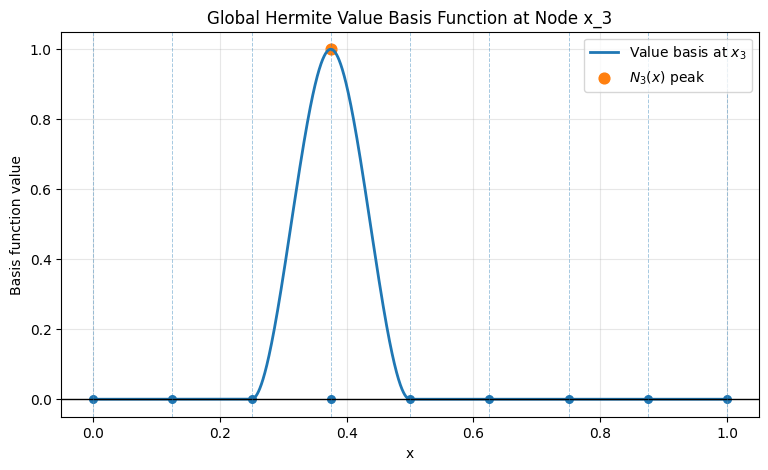

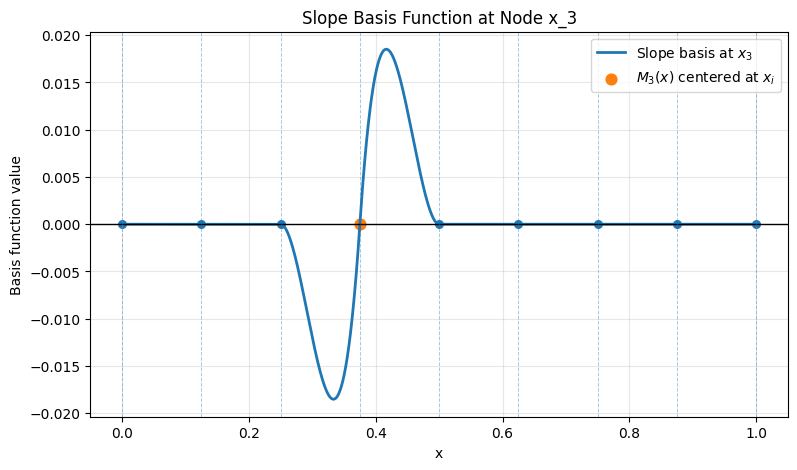

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Local Hermite cubic basis functions on [a,b]
# DOF ordering: [u(a), u'(a), u(b), u'(b)]
# ============================================================

def H1(x, a, b):  # value at left node
    return ((x - b)**2 * (3*a - b - 2*x)) / (a - b)**3

def H2(x, a, b):  # slope at left node
    return ((x - b)**2 * (x - a)) / (a - b)**2

def H3(x, a, b):  # value at right node
    return ((x - a)**2 * (3*b - a - 2*x)) / (b - a)**3

def H4(x, a, b):  # slope at right node
    return ((x - a)**2 * (x - b)) / (b - a)**2


# ============================================================
# Build GLOBAL basis functions centered at node x_i
# ============================================================

def value_basis_global(x, nodes, i):
    """
    Global Hermite basis function associated with u(x_i).
    Support only on [x_{i-1}, x_{i+1}]
    """
    y = np.zeros_like(x)

    # left element [x_{i-1}, x_i]
    if i > 0:
        a, b = nodes[i-1], nodes[i]
        mask = (x >= a) & (x <= b)
        y[mask] = H3(x[mask], a, b)   # right value basis on left element

    # right element [x_i, x_{i+1}]
    if i < len(nodes)-1:
        a, b = nodes[i], nodes[i+1]
        mask = (x >= a) & (x <= b)
        y[mask] = H1(x[mask], a, b)   # left value basis on right element

    return y


def slope_basis_global(x, nodes, i):
    """
    Global Hermite basis function associated with u'(x_i).
    Support only on [x_{i-1}, x_{i+1}]
    """
    y = np.zeros_like(x)

    # left element [x_{i-1}, x_i]
    if i > 0:
        a, b = nodes[i-1], nodes[i]
        mask = (x >= a) & (x <= b)
        y[mask] = H4(x[mask], a, b)   # right slope basis on left element

    # right element [x_i, x_{i+1}]
    if i < len(nodes)-1:
        a, b = nodes[i], nodes[i+1]
        mask = (x >= a) & (x <= b)
        y[mask] = H2(x[mask], a, b)   # left slope basis on right element

    return y


# ============================================================
# PARAMETERS
# ============================================================

N = 8              # number of intervals
L = 1.0            # domain length [0,L]
i = 3              # choose interior node index (must be 1 <= i <= N-1)

nodes = np.linspace(0, L, N+1)
h = nodes[1] - nodes[0]

x = np.linspace(0, L, 2000)

# build basis functions centered at x_i
phi_val = value_basis_global(x, nodes, i)
phi_slope = slope_basis_global(x, nodes, i)

# ============================================================
# PLOT 1: value basis function centered at x_i
# ============================================================

plt.figure(figsize=(9,5))
plt.plot(x, phi_val, linewidth=2, label=rf'Value basis at $x_{i}$')
plt.axhline(0, linewidth=1, color='black')

for xn in nodes:
    plt.axvline(xn, linestyle='--', linewidth=0.7, alpha=0.4)

plt.scatter(nodes, np.zeros_like(nodes), s=30)
plt.scatter([nodes[i]], [1], s=60, label=rf'$N_{i}(x)$ peak')

plt.title(f"Value Basis Function at Node x_{i}")
plt.xlabel("x")
plt.ylabel("Basis function value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# PLOT 2: slope basis function centered at x_i
# ============================================================

plt.figure(figsize=(9,5))
plt.plot(x, phi_slope, linewidth=2, label=rf'Slope basis at $x_{i}$')
plt.axhline(0, linewidth=1, color='black')

for xn in nodes:
    plt.axvline(xn, linestyle='--', linewidth=0.7, alpha=0.4)

plt.scatter(nodes, np.zeros_like(nodes), s=30)
plt.scatter([nodes[i]], [0], s=60, label=rf'$M_{i}(x)$ centered at $x_i$')

plt.title(f"Slope Basis Function at Node x_{i}")
plt.xlabel("x")
plt.ylabel("Basis function value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

import numpy as np

# -------------------------------------------------------------------
import numpy as np

# ============================================================
# Hermite cubic basis functions on [a,b]
# ============================================================

def phi1(x, a, b):
    return ((x - b)**2 * (3*a - b - 2*x)) / (a - b)**3

def phi2(x, a, b):
    return ((x - b)**2 * (x - a)) / (a - b)**2

def phi3(x, a, b):
    return ((x - a)**2 * (3*b - a - 2*x)) / (b - a)**3

def phi4(x, a, b):
    return ((x - a)**2 * (x - b)) / (b - a)**2


# ============================================================
# First derivatives (optional, useful for checking)
# ============================================================

def dphi1(x, a, b):
    h = b - a
    return 6*(x - a)*(x - b)/h**3

def dphi2(x, a, b):
    h = b - a
    return ((x - b)*(3*x - 2*a - b))/h**2

def dphi3(x, a, b):
    h = b - a
    return -6*(x - a)*(x - b)/h**3

def dphi4(x, a, b):
    h = b - a
    return ((x - a)*(3*x - a - 2*b))/h**2


# ============================================================
# Second derivatives (these are what you need for stiffness)
# ============================================================

def ddphi1(x, a, b):
    h = b - a
    return 6*(-2*x + a + b)/h**3

def ddphi2(x, a, b):
    h = b - a
    return 2*(-3*x + 2*a + b)/h**2

def ddphi3(x, a, b):
    h = b - a
    return 6*(2*x - a - b)/h**3

def ddphi4(x, a, b):
    h = b - a
    return 2*(3*x - a - 2*b)/h**2

# 2-point Gauss-Legendre quadrature on [-1,1]
gauss_pts = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
gauss_wts = np.array([1.0, 1.0])

def local_stiffness(a, b):
    h = b - a
    K = np.zeros((4,4))

    dd_basis = [ddphi1, ddphi2, ddphi3, ddphi4]

    for q in range(2):
        xi = gauss_pts[q]
        w = gauss_wts[q]

        # map reference point xi in [-1,1] to physical point xq in [a,b]
        xq = 0.5*(a+b) + 0.5*h*xi
        J = h/2

        vals = np.array([f(xq, a, b) for f in dd_basis])

        for i in range(4):
            for j in range(4):
                K[i,j] += w * vals[i] * vals[j] * J

    return K


# Example
K = local_stiffness(0.0, 1.0)
print(np.round(K, 8))

[[ 12.   6. -12.  -6.]
 [  6.   4.  -6.  -2.]
 [-12.  -6.  12.   6.]
 [ -6.  -2.   6.   4.]]


In [ ]:
# ============================================================
# Exact local stiffness matrix for one Hermite cubic element
# ============================================================

def local_stiffness_exact(h):
    return np.array([
        [ 12/h**3,  6/h**2, -12/h**3,  6/h**2],
        [  6/h**2,   4/h,    -6/h**2,   2/h   ],
        [-12/h**3, -6/h**2,  12/h**3, -6/h**2],
        [  6/h**2,   2/h,    -6/h**2,   4/h   ]
    ], dtype=float)

# ============================================================
# Assemble global stiffness matrix
# ============================================================

def assemble_global_stiffness(N, L=1.0):
    h = L / N
    ndofs = 2 * (N + 1)   # u_i and m_i at each node
    K_global = np.zeros((ndofs, ndofs))

    Ke = local_stiffness_exact(h)

    for k in range(N):
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]

        for i in range(4):
            for j in range(4):
                K_global[idx[i], idx[j]] += Ke[i, j]

    return K_global

# ============================================================
# Example using the previously declared N
# ============================================================
K_global = assemble_global_stiffness(N)

In [ ]:
# Interior/free DOFs only
free_dofs = list(range(2, 2*N))

# Reduced matrix
K_reduced = K_global[np.ix_(free_dofs, free_dofs)]

print("Full K shape:", K_global.shape)
print("Reduced K shape:", K_reduced.shape)

Full K shape: (18, 18)
Reduced K shape: (14, 14)


[ 0.00000000e+00  0.00000000e+00 -2.60416667e-03 -1.56250000e-02
 -5.20833333e-03 -4.62592927e-18 -2.60416667e-03  1.56250000e-02
  0.00000000e+00  0.00000000e+00]


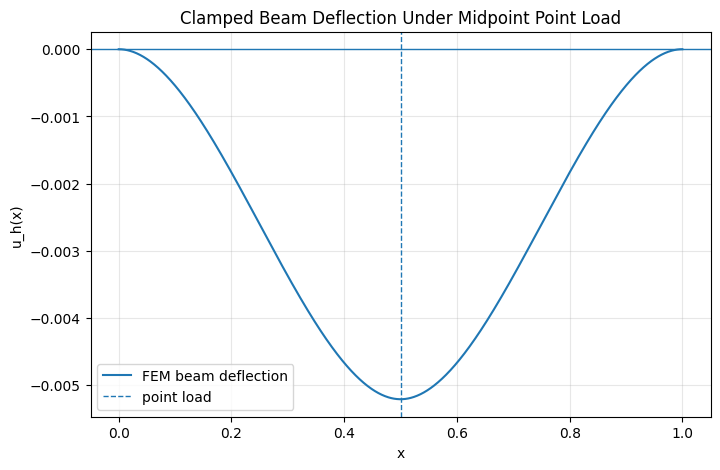

In [ ]:
def assemble_global_stiffness(N, L=1.0):
    h = L / N
    ndofs = 2 * (N + 1)
    K_global = np.zeros((ndofs, ndofs))
    Ke = local_stiffness_exact(h)

    for k in range(N):
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
        for i in range(4):
            for j in range(4):
                K_global[idx[i], idx[j]] += Ke[i, j]

    return K_global

# ============================================================
# Assemble point load P at x0
# ============================================================

def assemble_point_load(N, x0=0.5, P=-1.0, L=1.0):
    nodes = np.linspace(0, L, N+1)
    F = np.zeros(2*(N+1))

    # special case: if x0 is exactly a node, put load on value DOF
    for j, xj in enumerate(nodes):
        if np.isclose(x0, xj):
            F[2*j] = P
            return F

    # otherwise place into containing element
    for k in range(N):
        a, b = nodes[k], nodes[k+1]
        if a <= x0 <= b:
            idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
            Fe = P * np.array([
                phi1(x0, a, b),
                phi2(x0, a, b),
                phi3(x0, a, b),
                phi4(x0, a, b)
            ])
            for i in range(4):
                F[idx[i]] += Fe[i]
            break

    return F

# ============================================================
# Reduce system using clamped BCs
# ============================================================

def reduce_system(K_global, F_global, N):
    free_dofs = list(range(2, 2*N))
    K_red = K_global[np.ix_(free_dofs, free_dofs)]
    F_red = F_global[free_dofs]
    return K_red, F_red, free_dofs

# ============================================================
# Reconstruct full DOF vector
# ============================================================

def reconstruct_full_solution(U_red, N):
    U_full = np.zeros(2*(N+1))
    free_dofs = list(range(2, 2*N))
    U_full[free_dofs] = U_red
    return U_full

# ============================================================
# Evaluate FEM solution u_h(x)
# ============================================================

def evaluate_fem_solution(x_plot, U_full, N, L=1.0):
    nodes = np.linspace(0, L, N+1)
    uh = np.zeros_like(x_plot)

    for k in range(N):
        a, b = nodes[k], nodes[k+1]
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
        Uk = U_full[idx]

        mask = (x_plot >= a) & (x_plot <= b)
        x = x_plot[mask]

        uh[mask] = (
            Uk[0] * phi1(x, a, b) +
            Uk[1] * phi2(x, a, b) +
            Uk[2] * phi3(x, a, b) +
            Uk[3] * phi4(x, a, b)
        )

    return uh

# ============================================================
# Example solve
# ============================================================

N = 4
L = 1.0
P = -1.0
x_load = 0.5

K_global = assemble_global_stiffness(N, L)
F_global = assemble_point_load(N, x0=x_load, P=P, L=L)

K_red, F_red, free_dofs = reduce_system(K_global, F_global, N)

# Solve for unknown parameters
U_red = np.linalg.solve(K_red, F_red)

# Rebuild full vector including boundary zeros
U_full = reconstruct_full_solution(U_red, N)

# ============================================================
# Plot solution
# ============================================================

x_plot = np.linspace(0, L, 1000)
u_plot = evaluate_fem_solution(x_plot, U_full, N, L)

print(U_full)

plt.figure(figsize=(8,5))
plt.plot(x_plot, u_plot, label='FEM beam deflection')
plt.axvline(x_load, linestyle='--', linewidth=1, label='point load')
plt.axhline(0, linewidth=1)
plt.title("Clamped Beam Deflection Under Midpoint Point Load")
plt.xlabel("x")
plt.ylabel("u_h(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def assemble_sin_load(N, q=-1.0, L=1.0):
    """
    Assemble global load vector for constant distributed load f(x)=q
    over the entire beam.
    """
    h = L / N
    nodes = np.linspace(0, L, N+1)
    F = np.zeros(2*(N+1))

    # exact local load vector for constant q on one element
    Fe = q * np.array([
        h/2,
        h**2/12,
        h/2,
        -h**2/12
    ])

    for k in range(N):
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
        for i in range(4):
            F[idx[i]] += Fe[i] * np.sin(np.pi*h*k)

    return F

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Plot FEM solution with each element's cubic interpolant colored
# ============================================================

def plot_colored_interpolants(U_full, N, L=1.0, x_load=None, title="Piecewise Cubic FEM Interpolant"):
    nodes = np.linspace(0, L, N+1)
    u_nodes = U_full[0::2]   # displacement DOFs

    plt.figure(figsize=(9,5))
    cmap = plt.cm.viridis

    for k in range(N):
        a, b = nodes[k], nodes[k+1]
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
        Uk = U_full[idx]

        x_local = np.linspace(a, b, 200)

        u_local = (
            Uk[0] * phi1(x_local, a, b) +
            Uk[1] * phi2(x_local, a, b) +
            Uk[2] * phi3(x_local, a, b) +
            Uk[3] * phi4(x_local, a, b)
        )

        color = cmap(k / max(N-1, 1))
        plt.plot(x_local, u_local, linewidth=3, color=color, label=f"Element {k}" if N <= 10 else None)

    # nodal displacement values
    plt.scatter(nodes, u_nodes, color='black', zorder=5, label='nodal values')

    # mesh lines
    for xn in nodes:
        plt.axvline(xn, linestyle='--', linewidth=0.7, alpha=0.3, color='gray')
    plt.axhline(0, linewidth=1, color='black')
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel(r"$u_h(x)$")
    plt.grid(True, alpha=0.3)

    if N <= 10:
        plt.legend()

    plt.show()

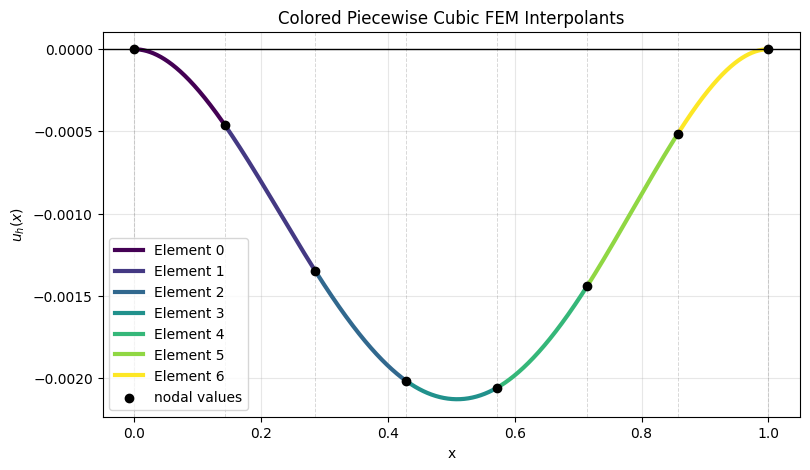

In [ ]:
N = 7
L = 1.0
q = -1.0
x_load = 0.5

K_global = assemble_global_stiffness(N, L)
F_global = assemble_sin_load(N, q=q, L=L)

K_red, F_red, free_dofs = reduce_system(K_global, F_global, N)

# Solve for unknown parameters
U_red = np.linalg.solve(K_red, F_red)

# Rebuild full vector including boundary zeros
U_full = reconstruct_full_solution(U_red, N)


plot_colored_interpolants(
    U_full,
    N,
    L=L,
    x_load=x_load,
    title="Colored Piecewise Cubic FEM Interpolants"
)

In [ ]:
# ============================================================
# Manufactured exact solution and corresponding load
# ============================================================

def u_exact(x):
    return np.sin(np.pi * x)**2

def f_manufactured(x):
    return -8 * np.pi**4 * np.cos(2 * np.pi * x)

In [ ]:
# ============================================================
# Assemble load vector for arbitrary distributed load f(x)
# ============================================================

def assemble_general_load(N, f, L=1.0):
    nodes = np.linspace(0, L, N+1)
    F = np.zeros(2*(N+1))

    # 4-point Gauss-Legendre quadrature on [-1,1]
    gauss_pts = np.array([
        -0.8611363116,
        -0.3399810436,
         0.3399810436,
         0.8611363116
    ])
    gauss_wts = np.array([
        0.3478548451,
        0.6521451549,
        0.6521451549,
        0.3478548451
    ])

    for k in range(N):
        a, b = nodes[k], nodes[k+1]
        h = b - a
        idx = [2*k, 2*k+1, 2*k+2, 2*k+3]
        Fe = np.zeros(4)

        for q in range(len(gauss_pts)):
            xi = gauss_pts[q]
            w = gauss_wts[q]

            # map [-1,1] -> [a,b]
            xq = 0.5*(a+b) + 0.5*h*xi
            J = h/2

            phi_vals = np.array([
                phi1(xq, a, b),
                phi2(xq, a, b),
                phi3(xq, a, b),
                phi4(xq, a, b)
            ])

            Fe += w * f(xq) * phi_vals * J

        for i in range(4):
            F[idx[i]] += Fe[i]

    return F

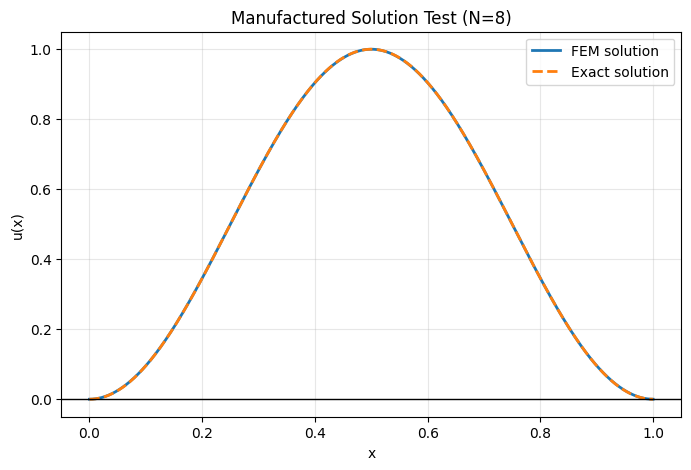

Max error = 0.0004531080431042292


In [ ]:
# ============================================================
# Single solve and comparison plot
# ============================================================

N = 8
L = 1.0

K_global = assemble_global_stiffness(N, L)
F_global = assemble_general_load(N, f_manufactured, L)

K_red, F_red, free_dofs = reduce_system(K_global, F_global, N)
U_red = np.linalg.solve(K_red, F_red)
U_full = reconstruct_full_solution(U_red, N)

x_plot = np.linspace(0, L, 2000)
u_num = evaluate_fem_solution(x_plot, U_full, N, L)
u_ex = u_exact(x_plot)

plt.figure(figsize=(8,5))
plt.plot(x_plot, u_num, label='FEM solution', linewidth=2)
plt.plot(x_plot, u_ex, '--', label='Exact solution', linewidth=2)
plt.axhline(0, linewidth=1, color='black')
plt.title(f"Manufactured Solution Test (N={N})")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

max_error = np.max(np.abs(u_num - u_ex))
print("Max error =", max_error)

In [ ]:
# ============================================================
# Convergence study
# ============================================================

N_values = [2, 4, 8, 16, 32, 64]
errors_inf = []
errors_l2 = []

x_ref = np.linspace(0, 1, 5000)
u_ref = u_exact(x_ref)

for N in N_values:
    K_global = assemble_global_stiffness(N, L=1.0)
    F_global = assemble_general_load(N, f_manufactured, L=1.0)

    K_red, F_red, free_dofs = reduce_system(K_global, F_global, N)
    U_red = np.linalg.solve(K_red, F_red)
    U_full = reconstruct_full_solution(U_red, N)

    u_num = evaluate_fem_solution(x_ref, U_full, N, L=1.0)

    err_inf = np.max(np.abs(u_num - u_ref))
    err_l2 = np.sqrt(np.trapz((u_num - u_ref)**2, x_ref))

    errors_inf.append(err_inf)
    errors_l2.append(err_l2)

    print(f"N={N:2d}   max error={err_inf:.6e}   L2 error={err_l2:.6e}")

N= 2   max error=1.010133e-02   L2 error=6.585244e-03
N= 4   max error=5.395595e-03   L2 error=3.425879e-03
N= 8   max error=4.531083e-04   L2 error=2.209941e-04
N=16   max error=3.029276e-05   L2 error=1.392118e-05
N=32   max error=1.924786e-06   L2 error=8.717840e-07
N=64   max error=1.207936e-07   L2 error=5.451276e-08


/var/folders/zr/wpwk00wd2ygcddp_nzg3ytfm0000gn/T/ipykernel_41889/540561785.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  err_l2 = np.sqrt(np.trapz((u_num - u_ref)**2, x_ref))


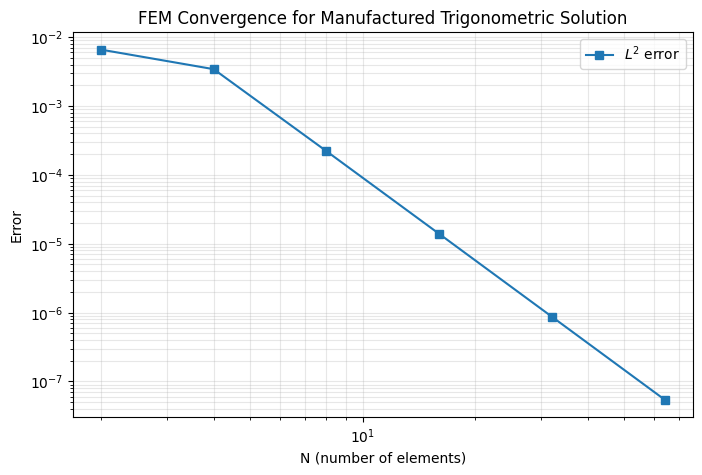

In [ ]:
# ============================================================
# Plot convergence
# ============================================================

plt.figure(figsize=(8,5))
plt.loglog(N_values, errors_l2, 's-', label=r'$L^2$ error')
plt.xlabel("N (number of elements)")
plt.ylabel("Error")
plt.title("FEM Convergence for Manufactured Trigonometric Solution")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

In [ ]:

print("\nEstimated convergence rates (L2 norm):")
for k in range(1, len(N_values)):
    rate = np.log(errors_l2[k-1]/errors_l2[k]) / np.log(N_values[k]/N_values[k-1])
    print(f"{N_values[k-1]:2d} -> {N_values[k]:2d}: rate ~ {rate:.4f}")


Estimated convergence rates (L2 norm):
 2 ->  4: rate ~ 0.9428
 4 ->  8: rate ~ 3.9544
 8 -> 16: rate ~ 3.9887
16 -> 32: rate ~ 3.9972
32 -> 64: rate ~ 3.9993
